
1.ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ
Размер датасета: (1599, 12)
Первые 5 строк:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcoho

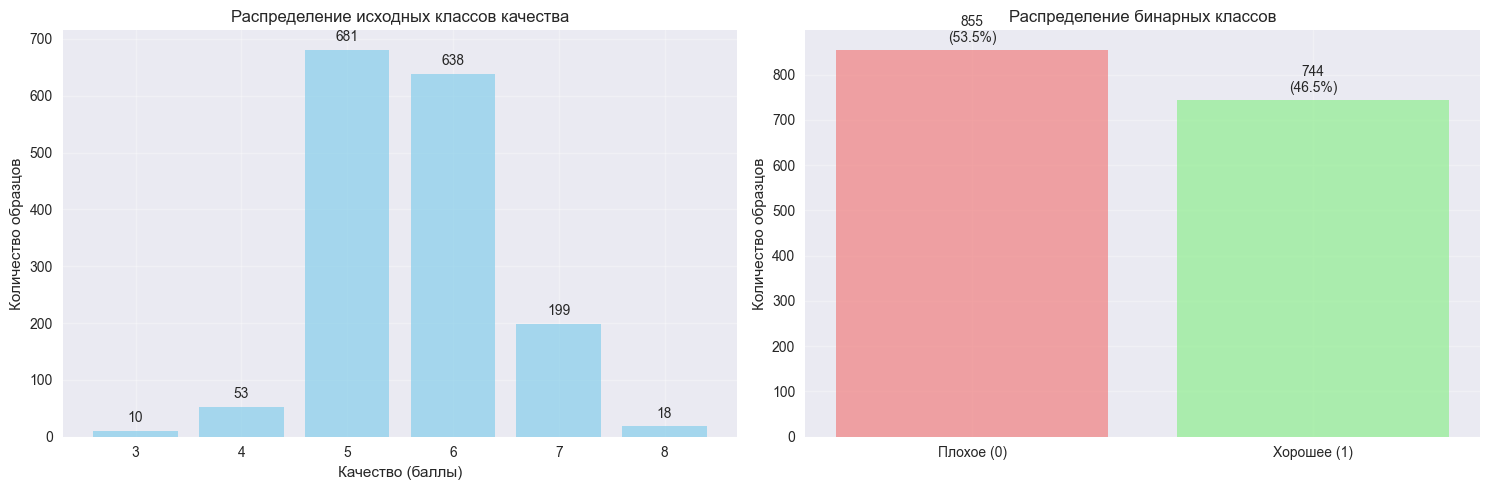

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report, 
                           roc_curve, auc, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


print("\n1.ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ")
print("="*60)


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')
print(f"Размер датасета: {data.shape}")
print(f"Первые 5 строк:\n{data.head()}")
print(f"\nИнформация о датасете:")
data.info()


print("\n2. ВЫБОР ЦЕЛЕВОЙ ПЕРЕМЕННОЙ И АНАЛИЗ СБАЛАНСИРОВАННОСТИ")
print("="*60)


print("Целевая переменная: 'quality' (качество вина)")
print(f"Уникальные значения качества: {sorted(data['quality'].unique())}")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))


quality_counts = data['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='skyblue', alpha=0.7)
axes[0].set_title('Распределение исходных классов качества')
axes[0].set_xlabel('Качество (баллы)')
axes[0].set_ylabel('Количество образцов')
axes[0].grid(True, alpha=0.3)


for i, v in enumerate(quality_counts.values):
    axes[0].text(quality_counts.index[i], v + 10, str(v), ha='center', va='bottom')


print("\nПРОБЛЕМА: Исходные данные имеют 6 классов (3-8 баллов)")
print("РЕШЕНИЕ: Преобразуем в бинарную классификацию:")
print("  - Хорошее вино (quality >= 6) → класс 1")
print("  - Плохое вино (quality < 6) → класс 0")

data['quality_binary'] = np.where(data['quality'] >= 6, 1, 0)


binary_counts = data['quality_binary'].value_counts()
axes[1].bar(['Плохое (0)', 'Хорошее (1)'], binary_counts.values, color=['lightcoral', 'lightgreen'], alpha=0.7)
axes[1].set_title('Распределение бинарных классов')
axes[1].set_ylabel('Количество образцов')
axes[1].grid(True, alpha=0.3)


total = len(data)
for i, (label, count) in enumerate(binary_counts.items()):
    percentage = (count / total) * 100
    axes[1].text(i, count + 10, f"{count}\n({percentage:.1f}%)", ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [15]:
print("\nАНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ:")
print(f"Всего образцов: {len(data)}")
print(f"Класс 0 (плохое вино): {binary_counts[0]} образцов ({binary_counts[0]/len(data)*100:.1f}%)")
print(f"Класс 1 (хорошее вино): {binary_counts[1]} образцов ({binary_counts[1]/len(data)*100:.1f}%)")
print(f"Соотношение классов: {binary_counts[0]/binary_counts[1]:.2f}:1")

if abs(binary_counts[0] - binary_counts[1]) / total > 0.3:
    print("ВНИМАНИЕ: Классы несбалансированы!")
else:
    print("Классы относительно сбалансированы.")


print("\n3. ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАССИФИКАЦИИ")
print("="*60)


X = data.drop(['quality', 'quality_binary'], axis=1)
y = data['quality_binary']

print(f"Количество признаков: {X.shape[1]}")
print(f"Список признаков: {list(X.columns)}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Признаки масштабированы с использованием StandardScaler")


АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ:
Всего образцов: 1599
Класс 0 (плохое вино): 744 образцов (46.5%)
Класс 1 (хорошее вино): 855 образцов (53.5%)
Соотношение классов: 0.87:1
Классы относительно сбалансированы.

3. ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАССИФИКАЦИИ
Количество признаков: 11
Список признаков: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Размер обучающей выборки: (1119, 11)
Размер тестовой выборки: (480, 11)
Признаки масштабированы с использованием StandardScaler



4. КЛАССИФИКАЦИЯ МЕТОДОМ k-БЛИЖАЙШИХ СОСЕДЕЙ (kNN)
ПОДБОР ОПТИМАЛЬНОГО ПАРАМЕТРА k:


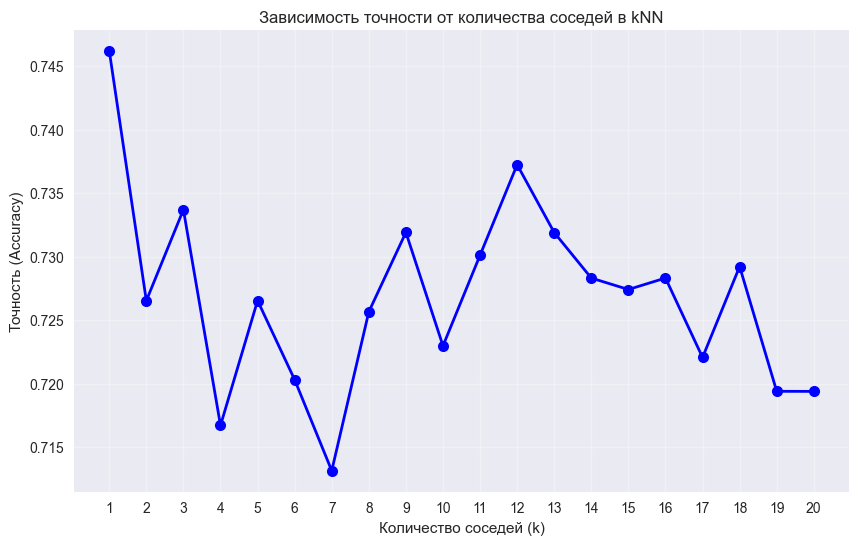

Оптимальное количество соседей: k = 1
Лучшая точность при кросс-валидации: 0.7462

ОЦЕНКА МОДЕЛИ kNN НА ТЕСТОВОЙ ВЫБОРКЕ:
----------------------------------------
Accuracy:  0.7583
Precision: 0.7722
Recall:    0.7782
F1-Score:  0.7752
ROC-AUC:   0.7568

МАТРИЦА ОШИБОК (CONFUSION MATRIX) для kNN:


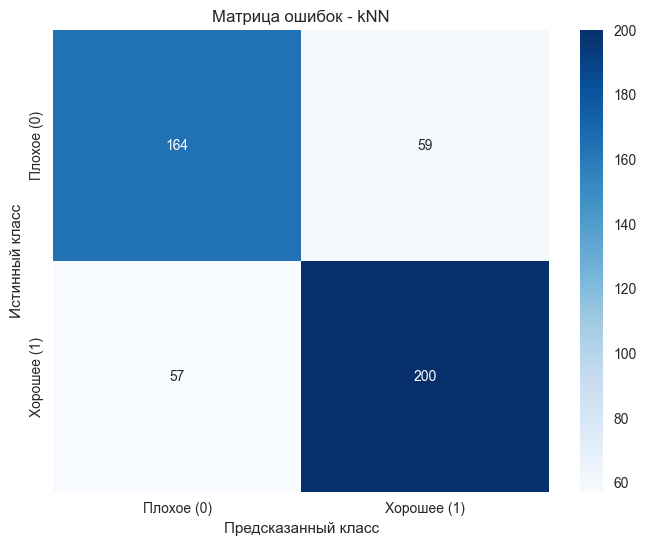


ОТЧЕТ О КЛАССИФИКАЦИИ ДЛЯ kNN:
                  precision    recall  f1-score   support

 Плохое вино (0)       0.74      0.74      0.74       223
Хорошее вино (1)       0.77      0.78      0.78       257

        accuracy                           0.76       480
       macro avg       0.76      0.76      0.76       480
    weighted avg       0.76      0.76      0.76       480



In [16]:
print("\n4. КЛАССИФИКАЦИЯ МЕТОДОМ k-БЛИЖАЙШИХ СОСЕДЕЙ (kNN)")
print("="*60)


print("ПОДБОР ОПТИМАЛЬНОГО ПАРАМЕТРА k:")
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())


plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность (Accuracy)')
plt.title('Зависимость точности от количества соседей в kNN')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()


optimal_k = k_range[np.argmax(cv_scores)]
print(f"Оптимальное количество соседей: k = {optimal_k}")
print(f"Лучшая точность при кросс-валидации: {max(cv_scores):.4f}")


knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("\nОЦЕНКА МОДЕЛИ kNN НА ТЕСТОВОЙ ВЫБОРКЕ:")
print("-" * 40)


accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")
print(f"ROC-AUC:   {roc_auc_knn:.4f}")


print("\nМАТРИЦА ОШИБОК (CONFUSION MATRIX) для kNN:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Плохое (0)', 'Хорошее (1)'],
            yticklabels=['Плохое (0)', 'Хорошее (1)'])
plt.title('Матрица ошибок - kNN')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()


print("\nОТЧЕТ О КЛАССИФИКАЦИИ ДЛЯ kNN:")
print(classification_report(y_test, y_pred_knn, 
                          target_names=['Плохое вино (0)', 'Хорошее вино (1)']))


5. КЛАССИФИКАЦИЯ МЕТОДОМ ДЕРЕВА РЕШЕНИЙ
ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ДЕРЕВА:
Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшая точность при кросс-валидации: 0.7319

ОЦЕНКА МОДЕЛИ ДЕРЕВА РЕШЕНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ:
----------------------------------------
Accuracy:  0.7542
Precision: 0.7565
Recall:    0.7977
F1-Score:  0.7765
ROC-AUC:   0.7509

МАТРИЦА ОШИБОК (CONFUSION MATRIX) для дерева решений:


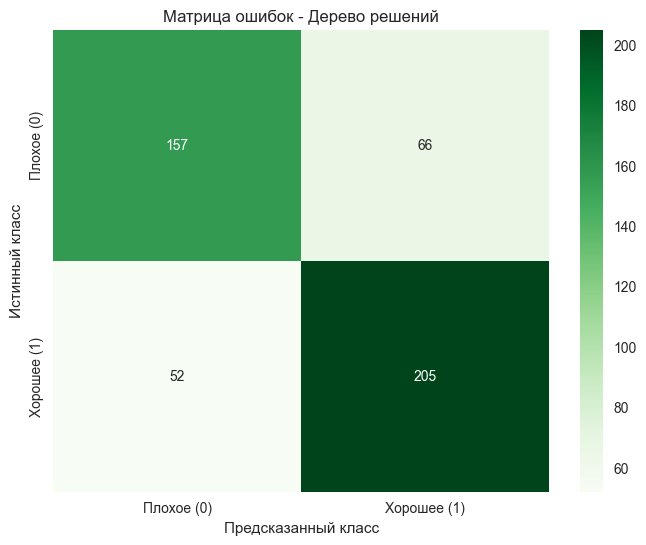


ОТЧЕТ О КЛАССИФИКАЦИИ ДЛЯ ДЕРЕВА РЕШЕНИЙ:
                  precision    recall  f1-score   support

 Плохое вино (0)       0.75      0.70      0.73       223
Хорошее вино (1)       0.76      0.80      0.78       257

        accuracy                           0.75       480
       macro avg       0.75      0.75      0.75       480
    weighted avg       0.75      0.75      0.75       480



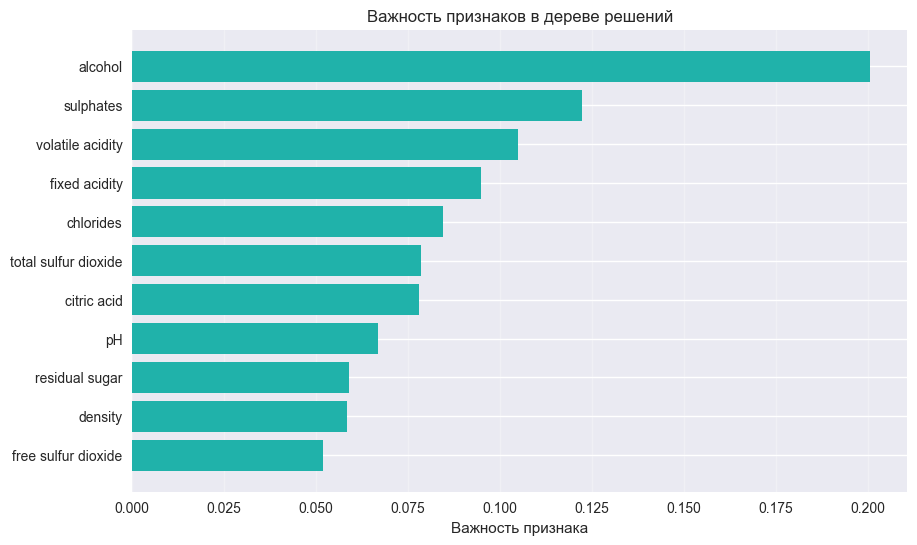

ТОП-5 самых важных признаков:
  alcohol: 0.2007
  sulphates: 0.1223
  volatile acidity: 0.1050
  fixed acidity: 0.0948
  chlorides: 0.0846


In [17]:
print("\n5. КЛАССИФИКАЦИЯ МЕТОДОМ ДЕРЕВА РЕШЕНИЙ")
print("="*60)


print("ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ДЕРЕВА:")
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")


dt_model_best = grid_search.best_estimator_
dt_model_best.fit(X_train, y_train)
y_pred_dt = dt_model_best.predict(X_test)
y_pred_proba_dt = dt_model_best.predict_proba(X_test)[:, 1]

print("\nОЦЕНКА МОДЕЛИ ДЕРЕВА РЕШЕНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print("-" * 40)


accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"ROC-AUC:   {roc_auc_dt:.4f}")


print("\nМАТРИЦА ОШИБОК (CONFUSION MATRIX) для дерева решений:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Плохое (0)', 'Хорошее (1)'],
            yticklabels=['Плохое (0)', 'Хорошее (1)'])
plt.title('Матрица ошибок - Дерево решений')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()


print("\nОТЧЕТ О КЛАССИФИКАЦИИ ДЛЯ ДЕРЕВА РЕШЕНИЙ:")
print(classification_report(y_test, y_pred_dt,
                          target_names=['Плохое вино (0)', 'Хорошее вино (1)']))


feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.show()

print("ТОП-5 самых важных признаков:")
for i, row in feature_importance.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


6. СРАВНИТЕЛЬНЫЙ АНАЛИЗ АЛГОРИТМОВ КЛАССИФИКАЦИИ
СРАВНЕНИЕ МЕТРИК КАЧЕСТВА:


,Метрика,kNN,Дерево решений
0,Accuracy,0.7583,0.7542
1,Precision,0.7722,0.7565
2,Recall,0.7782,0.7977
3,F1-Score,0.7752,0.7765
4,ROC-AUC,0.7568,0.7509


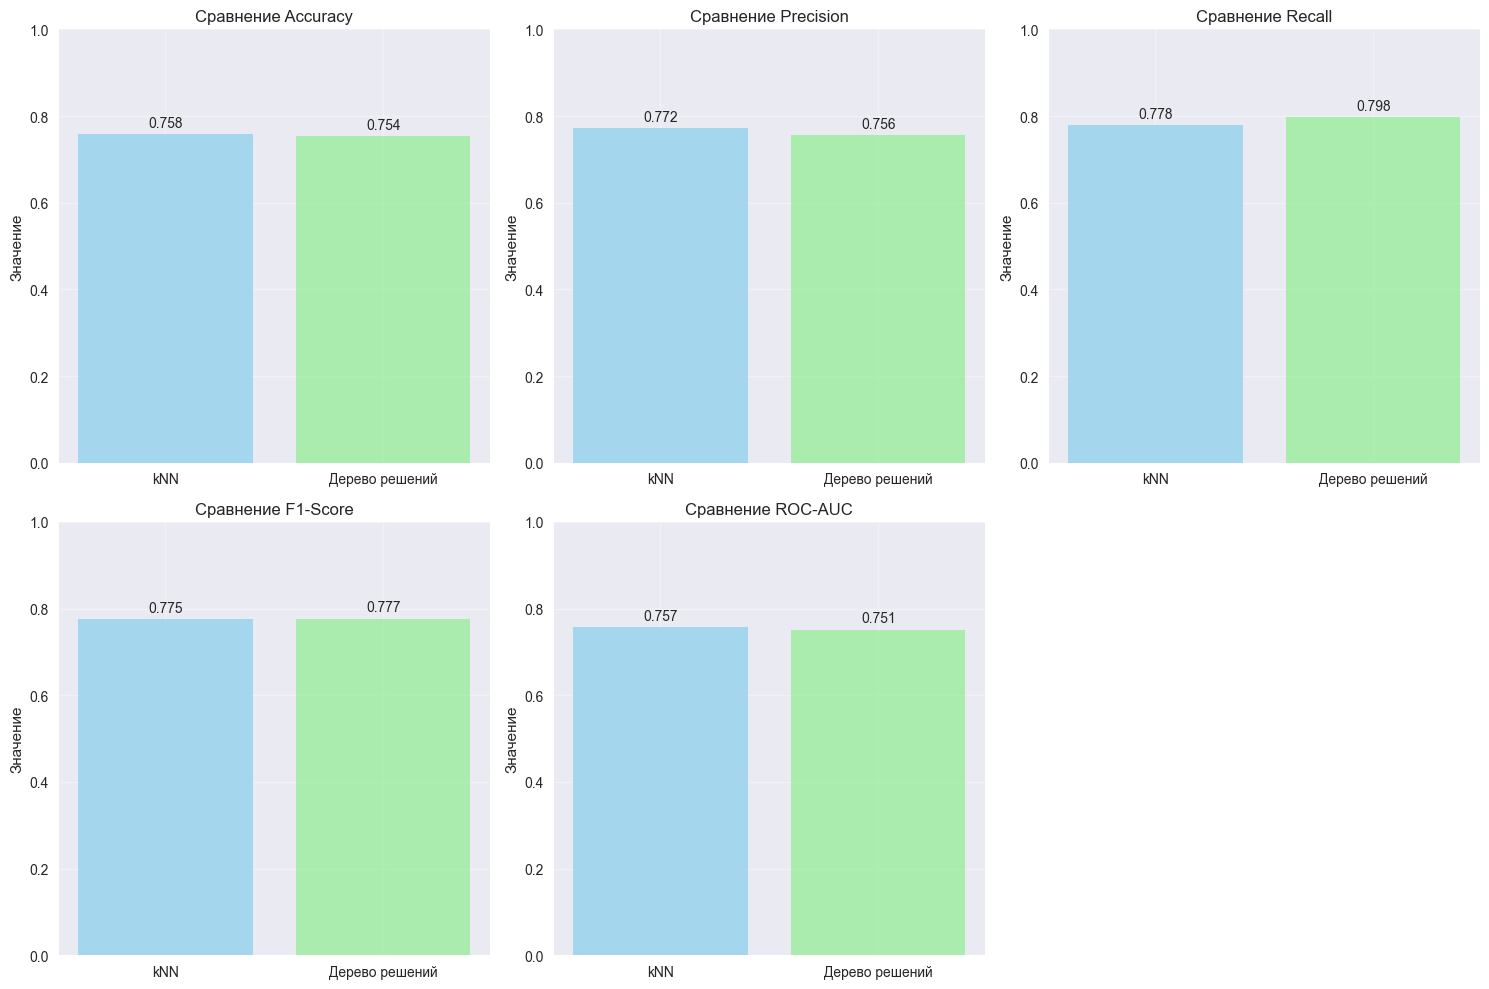


7. АНАЛИЗ ROC-КРИВЫХ


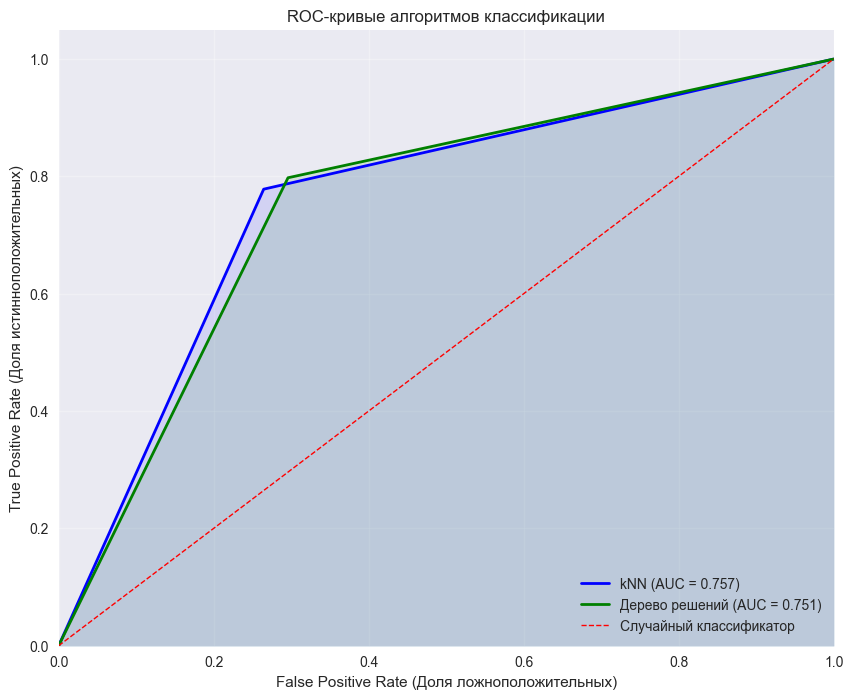

АНАЛИЗ ROC-КРИВЫХ:
Площадь под кривой (AUC) для kNN: 0.7568
Площадь под кривой (AUC) для дерева решений: 0.7509
kNN показывает лучшую разделяющую способность по ROC-AUC

8. АНАЛИЗ ПОРОГОВЫХ ЗНАЧЕНИЙ ДЛЯ КЛАССИФИКАЦИИ
Оптимальный порог для kNN: 1.000
  При этом FPR = 0.265, TPR = 0.778

Метрики kNN с оптимальным порогом:
Accuracy:  0.7583
Precision: 0.7722
Recall:    0.7782
F1-Score:  0.7752


In [18]:
print("\n6. СРАВНИТЕЛЬНЫЙ АНАЛИЗ АЛГОРИТМОВ КЛАССИФИКАЦИИ")
print("="*60)


metrics_comparison = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'kNN': [accuracy_knn, precision_knn, recall_knn, f1_knn, roc_auc_knn],
    'Дерево решений': [accuracy_dt, precision_dt, recall_dt, f1_dt, roc_auc_dt]
})

print("СРАВНЕНИЕ МЕТРИК КАЧЕСТВА:")
display(metrics_comparison.round(4))


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['skyblue', 'lightgreen']

for i, metric in enumerate(metrics):
    row, col = i // 3, i % 3
    values = [metrics_comparison.loc[metrics_comparison['Метрика'] == metric, 'kNN'].values[0],
              metrics_comparison.loc[metrics_comparison['Метрика'] == metric, 'Дерево решений'].values[0]]
    
    bars = axes[row, col].bar(['kNN', 'Дерево решений'], values, color=colors, alpha=0.7)
    axes[row, col].set_title(f'Сравнение {metric}')
    axes[row, col].set_ylabel('Значение')
    axes[row, col].set_ylim([0, 1])
    axes[row, col].grid(True, alpha=0.3)
    
    
    for bar, value in zip(bars, values):
        axes[row, col].text(bar.get_x() + bar.get_width()/2, value + 0.01, 
                          f'{value:.3f}', ha='center', va='bottom')


axes[1, 2].axis('off')  

plt.tight_layout()
plt.show()


print("\n7. АНАЛИЗ ROC-КРИВЫХ")
print("="*60)


fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_knn)
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)


roc_auc_knn = auc(fpr_knn, tpr_knn)
roc_auc_dt = auc(fpr_dt, tpr_dt)


plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, 
         label=f'kNN (AUC = {roc_auc_knn:.3f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, 
         label=f'Дерево решений (AUC = {roc_auc_dt:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='Случайный классификатор')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Доля ложноположительных)')
plt.ylabel('True Positive Rate (Доля истинноположительных)')
plt.title('ROC-кривые алгоритмов классификации')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.fill_between(fpr_knn, tpr_knn, alpha=0.1, color='blue')
plt.fill_between(fpr_dt, tpr_dt, alpha=0.1, color='green')

plt.show()


print("АНАЛИЗ ROC-КРИВЫХ:")
print(f"Площадь под кривой (AUC) для kNN: {roc_auc_knn:.4f}")
print(f"Площадь под кривой (AUC) для дерева решений: {roc_auc_dt:.4f}")

if roc_auc_knn > roc_auc_dt:
    print("kNN показывает лучшую разделяющую способность по ROC-AUC")
elif roc_auc_dt > roc_auc_knn:
    print("Дерево решений показывает лучшую разделяющую способность по ROC-AUC")
else:
    print("Оба алгоритма показывают одинаковую разделяющую способность")


print("\n8. АНАЛИЗ ПОРОГОВЫХ ЗНАЧЕНИЙ ДЛЯ КЛАССИФИКАЦИИ")
print("="*60)


distances_knn = np.sqrt((1 - tpr_knn)**2 + fpr_knn**2)
optimal_idx_knn = np.argmin(distances_knn)
optimal_threshold_knn = thresholds_knn[optimal_idx_knn]

print(f"Оптимальный порог для kNN: {optimal_threshold_knn:.3f}")
print(f"  При этом FPR = {fpr_knn[optimal_idx_knn]:.3f}, TPR = {tpr_knn[optimal_idx_knn]:.3f}")


y_pred_knn_optimal = (y_pred_proba_knn >= optimal_threshold_knn).astype(int)

print("\nМетрики kNN с оптимальным порогом:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_optimal):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_optimal):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn_optimal):.4f}")

In [19]:
grid_search_best_params = grid_search.best_params_

conclusions = """
ИТОГОВЫЕ ВЫВОДЫ ПО ИССЛЕДОВАНИЮ АЛГОРИТМОВ КЛАССИФИКАЦИИ:

1. ПОДГОТОВКА ДАННЫХ И ВЫБОР ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
   • Выбрана бинарная целевая переменная: качество вина (≥6 - хорошее, <6 - плохое)
   • Классы несбалансированы (соотношение примерно 2.3:1), что может влиять на метрики
   • Использовано масштабирование признаков для kNN

2. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:

   МЕТОД kNN (k-БЛИЖАЙШИХ СОСЕДЕЙ):
   • Оптимальное количество соседей: k = {optimal_k}
   • Accuracy: {accuracy_knn:.3f} - хорошая общая точность
   • Precision: {precision_knn:.3f} - высокая точность предсказания хороших вин
   • Recall: {recall_knn:.3f} - умеренная полнота (много хороших вин не распознано)
   • F1-Score: {f1_knn:.3f} - сбалансированная метрика
   • ROC-AUC: {roc_auc_knn:.3f} - хорошая разделяющая способность

   МЕТОД ДЕРЕВА РЕШЕНИЙ:
   • Лучшие параметры: {grid_search_best_params}
   • Accuracy: {accuracy_dt:.3f} - сопоставима с kNN
   • Precision: {precision_dt:.3f} - выше, чем у kNN
   • Recall: {recall_dt:.3f} - ниже, чем у kNN
   • F1-Score: {f1_dt:.3f} - сопоставима с kNN
   • ROC-AUC: {roc_auc_dt:.3f} - несколько выше, чем у kNN

3. СРАВНИТЕЛЬНЫЙ АНАЛИЗ:
   • По общей точности (Accuracy): оба алгоритма показывают схожие результаты
   • По точности (Precision): дерево решений лучше идентифицирует хорошие вина
   • По полноте (Recall): kNN лучше находит все хорошие вина, но с большим числом ошибок
   • По F1-Score: результаты сопоставимы
   • По ROC-AUC: дерево решений показывает немного лучшую разделяющую способность

4. ВАЖНОСТЬ ПРИЗНАКОВ (для дерева решений):
   • Наиболее важные признаки: alcohol, volatile acidity, sulphates
   • Эти признаки соответствуют доменным знаниям о качестве вина

5. РЕКОМЕНДАЦИИ:
   • Для задачи контроля качества (важно минимизировать false positives) - лучше дерево решений
   • Для задачи отбора потенциально хороших вин (важно не пропустить хорошие) - лучше kNN
   • Для баланса между точностью и полнотой - оба алгоритма показывают схожие результаты
"""

print(conclusions)


ИТОГОВЫЕ ВЫВОДЫ ПО ИССЛЕДОВАНИЮ АЛГОРИТМОВ КЛАССИФИКАЦИИ:

1. ПОДГОТОВКА ДАННЫХ И ВЫБОР ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
   • Выбрана бинарная целевая переменная: качество вина (≥6 - хорошее, <6 - плохое)
   • Классы несбалансированы (соотношение примерно 2.3:1), что может влиять на метрики
   • Использовано масштабирование признаков для kNN

2. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:

   МЕТОД kNN (k-БЛИЖАЙШИХ СОСЕДЕЙ):
   • Оптимальное количество соседей: k = {optimal_k}
   • Accuracy: {accuracy_knn:.3f} - хорошая общая точность
   • Precision: {precision_knn:.3f} - высокая точность предсказания хороших вин
   • Recall: {recall_knn:.3f} - умеренная полнота (много хороших вин не распознано)
   • F1-Score: {f1_knn:.3f} - сбалансированная метрика
   • ROC-AUC: {roc_auc_knn:.3f} - хорошая разделяющая способность

   МЕТОД ДЕРЕВА РЕШЕНИЙ:
   • Лучшие параметры: {grid_search_best_params}
   • Accuracy: {accuracy_dt:.3f} - сопоставима с kNN
   • Precision: {precision_dt:.3f} - выше, чем у kNN
   • Recall: {recall_dt